alpha0 5th-percentile floor: 0.001000

=== Coefficient diagnostics ===
  alpha0 range:  0.00100 – 0.00849
  alpha_safe min:0.00100  (floor applied)
  C0 range:      155.1 – 4100.0 m/yr
  D0 range:      124014507.2 – 670966627.2 m²/yr
  dD0dx range:   -23886.2 – 4580.6 m/yr
  eff_speed max: 27764.0 m/yr

=== Pe along flowline ===
  x=   0 km | alpha=0.00319 | Pe=0.012
  x=  37 km | alpha=0.00765 | Pe=0.459
  x=  75 km | alpha=0.00634 | Pe=0.642
  x= 112 km | alpha=0.00224 | Pe=0.319
  x= 150 km | alpha=0.00120 | Pe=0.226
  x= 187 km | alpha=0.00103 | Pe=0.240
  x= 225 km | alpha=0.00101 | Pe=0.281
  x= 262 km | alpha=0.00100 | Pe=0.328
  x= 300 km | alpha=0.00100 | Pe=0.375
dt = 0.002385 yr,  nt = 41,935


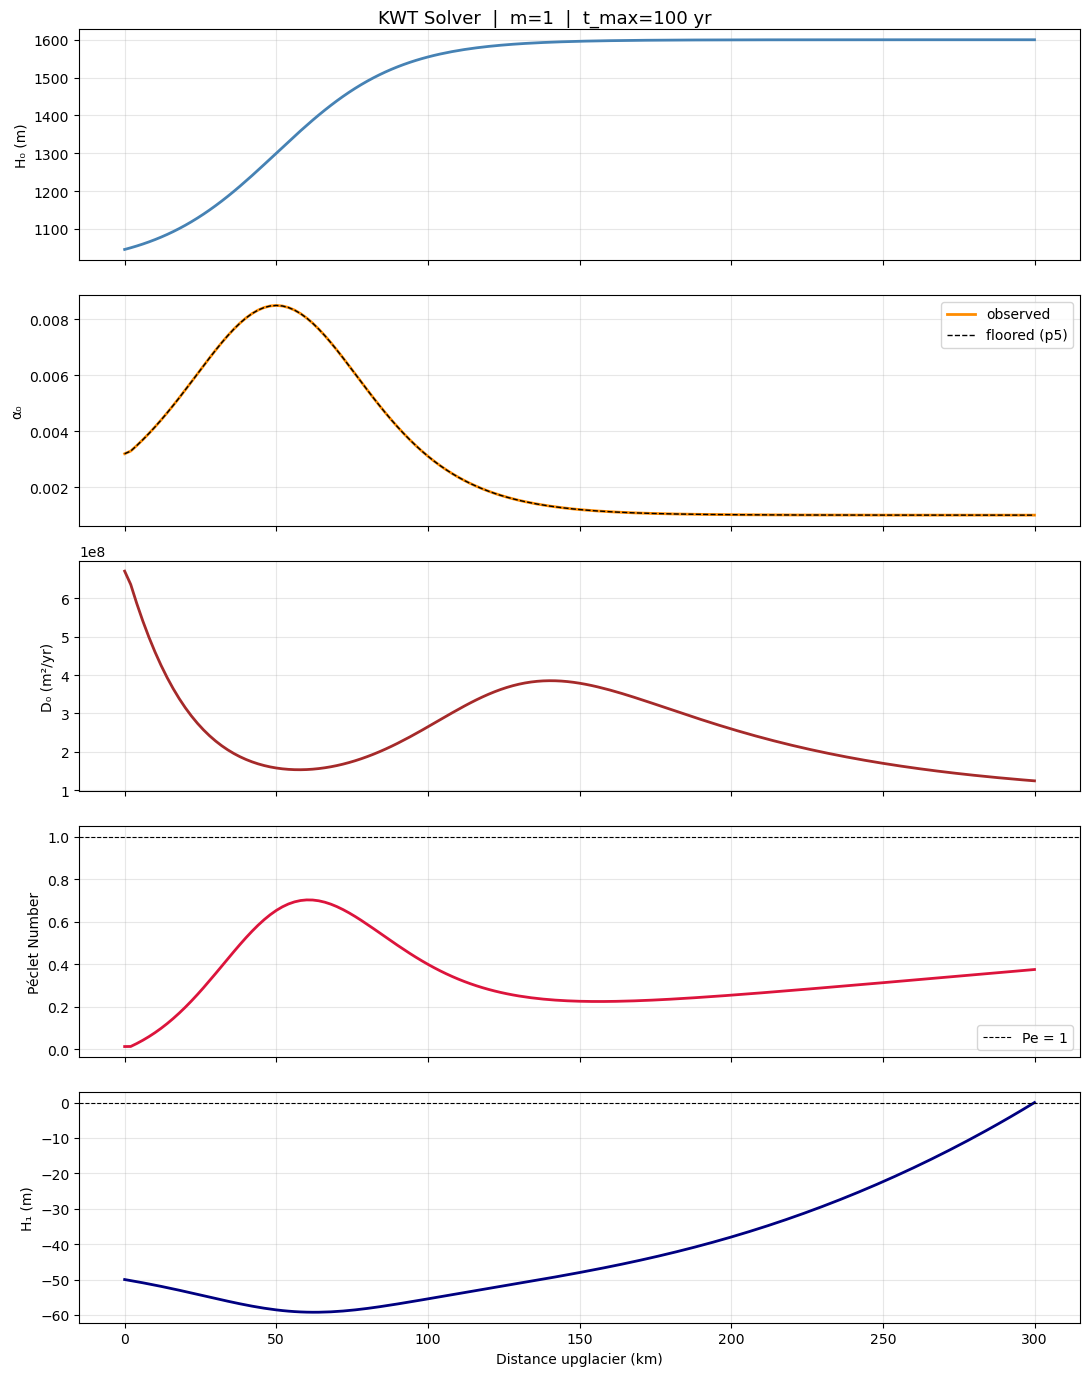

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded


def build_coefficients(u0, H0, alpha0, m, percentile_floor=5):
    """
    Build C0, D0 from observed fields.
    Floor on alpha0 set at a given percentile of the observed distribution
    — avoids arbitrary constants while preventing D0 blow-up in flat regions.
    """
    alpha_floor = np.percentile(alpha0, percentile_floor)
    alpha_safe  = np.maximum(alpha0, alpha_floor)

    C0 = (m + 1) * u0
    D0 = (m * u0 * H0) / alpha_safe

    return C0, D0, alpha_safe, alpha_floor


def run_kwt_solver(C0, D0, x, dh_front=-1*100, t_max=100):
    nx    = len(x)
    dx    = x[1] - x[0]

    dC0dx = np.gradient(C0, dx)
    dD0dx = np.gradient(D0, dx)

    # CFL based on actual effective advection speed
    eff_speed = np.abs(C0 - dD0dx)
    dt_adv    = 0.8 * dx / np.max(eff_speed)
    dt_diff   = 0.4 * dx**2 / np.max(D0)
    dt        = min(dt_adv, dt_diff, 0.5)
    nt        = int(t_max / dt)

    print(f"dt = {dt:.6f} yr,  nt = {nt:,}")

    # Crank-Nicolson matrix (diffusion implicit)
    r           = D0 * dt / dx**2
    ab          = np.zeros((3, nx))
    ab[1, 1:-1] = 1 + r[1:-1]
    ab[1, 0]    = 1.0
    ab[1, -1]   = 1.0
    ab[0, 2:]   = -0.5 * r[1:-1]
    ab[2, :-2]  = -0.5 * r[1:-1]

    H1    = np.zeros(nx)
    H1[0] = dh_front

    for step in range(nt):
        dH1dx     = np.zeros_like(H1)
        dH1dx[1:] = (H1[1:] - H1[:-1]) / dx

        # Explicit advection
        adv_term  = -(H1 * dC0dx + (C0 - dD0dx) * dH1dx)

        rhs        = H1.copy()
        rhs[1:-1] += (
            0.5 * r[1:-1] * (H1[2:] - 2*H1[1:-1] + H1[:-2])
            + dt * adv_term[1:-1]
        )
        rhs[0]  = dh_front
        rhs[-1] = 0.0

        H1      = solve_banded((1, 1), ab, rhs)
        H1[0]   = dh_front
        H1[-1]  = 0.0

        if not np.all(np.isfinite(H1)):
            print(f"⚠️  Divergence at step {step} (t={step*dt:.4f} yr).")
            break

    return H1


def compute_pe(C0, D0, x):
    l  = np.where(x > 0, x, x[1])
    return (C0 * l) / D0


def diagnostics(C0, D0, alpha0, alpha_safe, x):
    dD0dx   = np.gradient(D0, x[1] - x[0])
    Pe      = compute_pe(C0, D0, x)

    print("=== Coefficient diagnostics ===")
    print(f"  alpha0 range:  {alpha0.min():.5f} – {alpha0.max():.5f}")
    print(f"  alpha_safe min:{alpha_safe.min():.5f}  (floor applied)")
    print(f"  C0 range:      {C0.min():.1f} – {C0.max():.1f} m/yr")
    print(f"  D0 range:      {D0.min():.1f} – {D0.max():.1f} m²/yr")
    print(f"  dD0dx range:   {dD0dx.min():.1f} – {dD0dx.max():.1f} m/yr")
    print(f"  eff_speed max: {np.max(np.abs(C0 - dD0dx)):.1f} m/yr")
    print()
    print("=== Pe along flowline ===")
    dx = x[1] - x[0]
    for km in np.arange(0, x[-1]/1000 + 1, x[-1]/1000/8).astype(int):
        idx = np.argmin(np.abs(x - km * 1000))
        print(f"  x={km:4d} km | alpha={alpha_safe[idx]:.5f} | "
              f"Pe={Pe[idx]:.3f}")

    return Pe

def compute_strain_heating_increase(H0, H1, alpha0, x, n=3,
                                    alpha_percentile_floor=5):
    """
    Compute fractional increase in column-integrated strain heating
    due to thickness perturbation H1 and its induced slope change alpha1.

    Parameters
    ----------
    H0     : array, datum ice thickness (m)
    H1     : array, thickness perturbation from KWT solver (m)
    alpha0 : array, datum surface slope (m/m)
    x      : array, distance from terminus (m), uniform spacing
    n      : Glen's flow law exponent (default 3)
    alpha_percentile_floor : percentile of alpha0 used as floor (default 5)

    Returns
    -------
    dQ_pct   : array, strain heating increase (%)
    H_ratio  : array, thickness ratio (H0+H1)/H0
    alpha_ratio : array, slope ratio (alpha0+alpha1)/alpha0
    alpha1   : array, slope perturbation from H1 gradient
    """
    dx = x[1] - x[0]

    # ── Slope perturbation induced by H1 ─────────────────────────────────────
    alpha1 = np.gradient(H1, dx)

    # ── Floor alpha0 at its own percentile (same logic as build_coefficients) ─
    alpha_floor = np.percentile(alpha0, alpha_percentile_floor)
    alpha0_safe = np.maximum(alpha0, alpha_floor)

    # ── Ratios — clip to physically sane range ────────────────────────────────
    # H1 should be a small perturbation; negative H1 can't remove more ice
    # than exists, and we don't expect >2x thickening
    H0_safe   = np.maximum(H0, 1.0)
    H_ratio   = np.clip((H0_safe + H1) / H0_safe, 0.0, 5.0)

    # Slope ratio: perturbed slope shouldn't flip sign or be astronomically large
    alpha_perturbed = alpha0_safe + alpha1
    alpha_ratio     = np.clip(alpha_perturbed / alpha0_safe, 0.0, 5.0)

    # ── Strain heating increase ───────────────────────────────────────────────
    # dQ% = [(H_ratio * alpha_ratio)^(n+1) - 1] * 100
    tau_ratio = H_ratio * alpha_ratio
    dQ_pct    = (tau_ratio**(n + 1) - 1) * 100

    # ── Diagnostics ───────────────────────────────────────────────────────────
    print("=== Strain heating diagnostics ===")
    print(f"  alpha1 range:    {alpha1.min():.6f} – {alpha1.max():.6f}")
    print(f"  alpha0 floor:    {alpha_floor:.6f}")
    print(f"  H_ratio range:   {H_ratio.min():.3f} – {H_ratio.max():.3f}")
    print(f"  alpha_ratio range: {alpha_ratio.min():.3f} – {alpha_ratio.max():.3f}")
    print(f"  tau_ratio range: {tau_ratio.min():.3f} – {tau_ratio.max():.3f}")
    print(f"  dQ% range:       {dQ_pct.min():.1f} – {dQ_pct.max():.1f} %")

    return dQ_pct, H_ratio, alpha_ratio, alpha1


def plot_strain_heating(x, H0, H1, alpha0, alpha1, dQ_pct, t_max, m, n):
    fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)

    # H0 + H1
    axes[0].plot(x / 1000, H0, 'steelblue', lw=2, label='H₀')
    axes[0].plot(x / 1000, H0 + H1, 'navy', lw=2, ls='--', label='H₀+H₁')
    axes[0].fill_between(x / 1000, H0, H0 + H1,
                         alpha=0.15, color='navy', label='H₁')
    axes[0].set_ylabel("Ice thickness (m)")
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

    # alpha0 + alpha1
    axes[1].plot(x / 1000, alpha0, 'darkorange', lw=2, label='α₀')
    axes[1].plot(x / 1000, alpha0 + alpha1, 'saddlebrown',
                 lw=2, ls='--', label='α₀+α₁')
    axes[1].set_ylabel("Surface slope")
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

    # H1 profile
    axes[2].plot(x / 1000, H1, 'navy', lw=2)
    axes[2].axhline(0, color='k', lw=0.8, ls='--')
    axes[2].set_ylabel("H₁ (m)"); axes[2].grid(True, alpha=0.3)

    # Strain heating increase
    axes[3].plot(x / 1000, dQ_pct, 'crimson', lw=2)
    axes[3].axhline(0, color='k', lw=0.8, ls='--')
    axes[3].fill_between(x / 1000, 0, dQ_pct,
                         where=dQ_pct > 0, alpha=0.15, color='crimson')
    axes[3].fill_between(x / 1000, 0, dQ_pct,
                         where=dQ_pct < 0, alpha=0.15, color='steelblue')
    axes[3].set_ylabel("Strain heating\nincrease (%)")
    axes[3].set_xlabel("Distance upglacier (km)")
    axes[3].grid(True, alpha=0.3)

    plt.suptitle(
        f"Strain heating increase  |  m={m}, n={n}, t_max={t_max} yr",
        fontsize=13
    )
    plt.tight_layout()
    plt.show()



# ─────────────────────────────────────────────────────────────────────────────
# DROP YOUR OBSERVED DATA IN HERE
# ─────────────────────────────────────────────────────────────────────────────
# x      : 1-D array, distance upglacier from terminus (m), uniform spacing
# u0_obs : observed surface/sliding velocity (m/yr)
# H0_obs : observed ice thickness (m)
# alpha0_obs : observed surface slope (rad or m/m), same sign convention
#              (should be positive = sloping upward inland)
# ─────────────────────────────────────────────────────────────────────────────

# ── Placeholder synthetic stand-in (replace with real data) ──────────────────
nx = 151
x  = np.linspace(0, 300_000, nx)

H0_obs     = 1000 + 600 / (1 + np.exp(-(x - 50_000) / 20_000))
alpha0_obs = np.gradient(H0_obs, x) + 0.001
u0_obs     = 2000 * np.exp(-x / 70_000) + 50
# ─────────────────────────────────────────────────────────────────────────────
n        = 3
m        = 1
dh_front = -50
t_max    = 100

C0, D0, alpha_safe, alpha_floor = build_coefficients(
    u0_obs, H0_obs, alpha0_obs, m=m, percentile_floor=5
)

print(f"alpha0 5th-percentile floor: {alpha_floor:.6f}\n")
Pe = diagnostics(C0, D0, alpha0_obs, alpha_safe, x)

H1 = run_kwt_solver(C0, D0, x, dh_front=dh_front, t_max=t_max)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(11, 14), sharex=True)

axes[0].plot(x / 1000, H0_obs, 'steelblue', lw=2)
axes[0].set_ylabel("H₀ (m)"); axes[0].grid(True, alpha=0.3)

axes[1].plot(x / 1000, alpha0_obs, 'darkorange', lw=2, label='observed')
axes[1].plot(x / 1000, alpha_safe, 'k--', lw=1, label=f'floored (p{5})')
axes[1].set_ylabel("α₀"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(x / 1000, D0, 'brown', lw=2)
axes[2].set_ylabel("D₀ (m²/yr)"); axes[2].grid(True, alpha=0.3)

axes[3].plot(x / 1000, Pe, 'crimson', lw=2)
axes[3].axhline(1, color='k', lw=0.8, ls='--', label='Pe = 1')
axes[3].set_ylabel("Péclet Number"); axes[3].legend()
axes[3].grid(True, alpha=0.3)

axes[4].plot(x / 1000, H1, 'navy', lw=2)
axes[4].axhline(0, color='k', lw=0.8, ls='--')
axes[4].set_ylabel("H₁ (m)"); axes[4].set_xlabel("Distance upglacier (km)")
axes[4].grid(True, alpha=0.3)

plt.suptitle(f"KWT Solver  |  m={m}  |  t_max={t_max} yr", fontsize=13)
plt.tight_layout()
plt.show()


=== Strain heating diagnostics ===
  alpha1 range:    -0.000196 – 0.000520
  alpha0 floor:    0.001000
  H_ratio range:   0.952 – 1.000
  alpha_ratio range: 0.953 – 1.519
  tau_ratio range: 0.907 – 1.519
  dQ% range:       -32.2 – 433.1 %


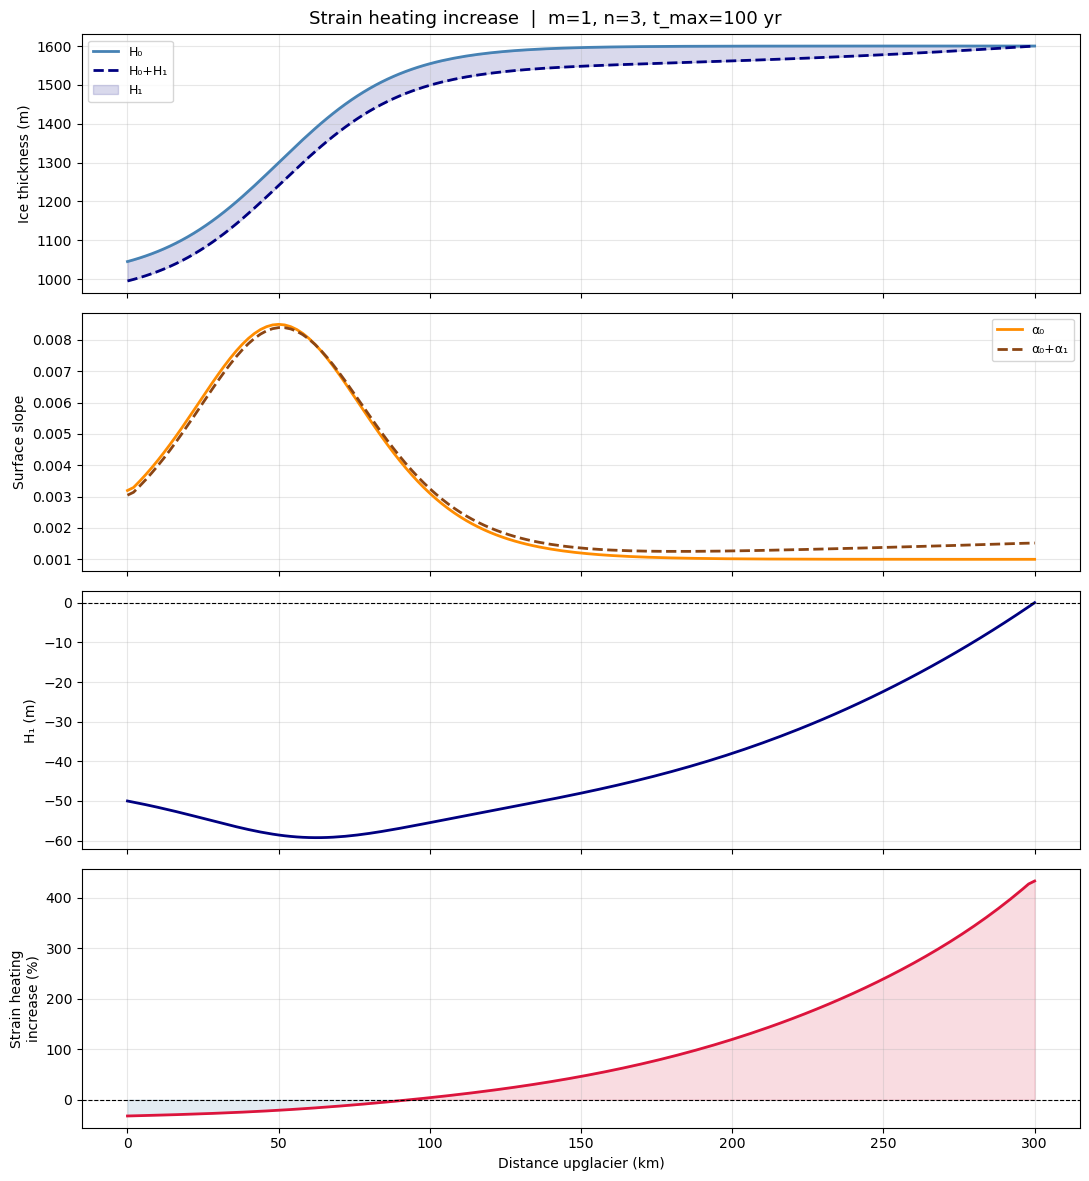

In [56]:
dQ_pct, H_ratio, alpha_ratio, alpha1 = compute_strain_heating_increase(
    H0=H0_obs, H1=H1, alpha0=alpha0_obs, x=x, n=n
)

plot_strain_heating(
    x=x, H0=H0_obs, H1=H1,
    alpha0=alpha0_obs, alpha1=alpha1,
    dQ_pct=dQ_pct, t_max=t_max, m=m, n=n
)


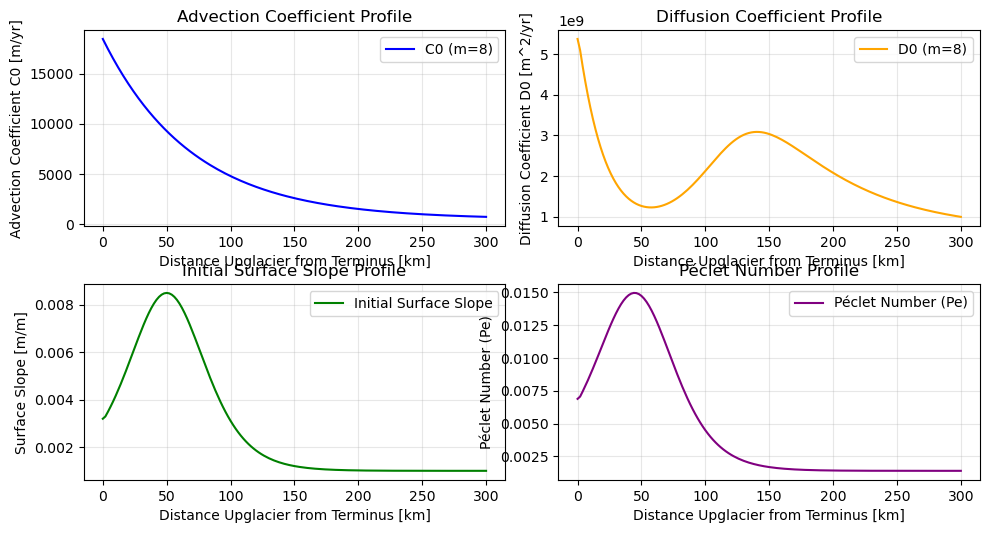

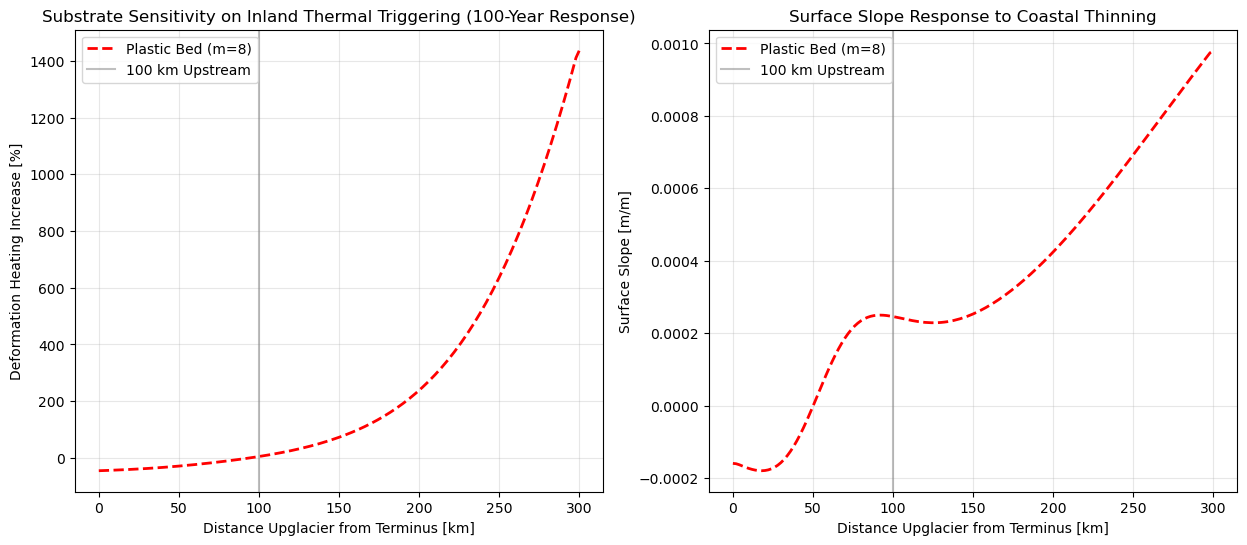

In [48]:
Pe = (C0 * (x[1] - x[0])) / D0

# visualize C0 and D0 profiles
plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.plot(x/1000, C0, label='C0 (m=8)', color='blue')
plt.xlabel('Distance Upglacier from Terminus [km]')
plt.ylabel('Advection Coefficient C0 [m/yr]')
plt.title('Advection Coefficient Profile')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(2, 2, 2)
plt.plot(x/1000, D0, label='D0 (m=8)', color='orange')
plt.xlabel('Distance Upglacier from Terminus [km]')
plt.ylabel('Diffusion Coefficient D0 [m^2/yr]')
plt.title('Diffusion Coefficient Profile')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plot initial surface slope and ice velocity
plt.subplot(2, 2, 3)
plt.plot(x/1000, alpha0, label='Initial Surface Slope', color='green')
plt.xlabel('Distance Upglacier from Terminus [km]')
plt.ylabel('Surface Slope [m/m]')
plt.title('Initial Surface Slope Profile')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(2, 2, 4)
plt.plot(x/1000, Pe, label='Péclet Number (Pe)', color='purple')
plt.xlabel('Distance Upglacier from Terminus [km]')
plt.ylabel('Péclet Number (Pe)')
plt.title('Péclet Number Profile')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Visualization
x_km = x / 1000
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(x_km, heat_plastic, label='Plastic Bed (m=8)', color='red', linestyle='--', linewidth=2)
plt.axvline(x=100, color='gray', alpha=0.5, label='100 km Upstream')
plt.xlabel('Distance Upglacier from Terminus [km]')
plt.ylabel('Deformation Heating Increase [%]')
plt.title('Substrate Sensitivity on Inland Thermal Triggering (100-Year Response)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1,2,2)
plt.plot(x_km, alpha_plastic, label='Plastic Bed (m=8)', color='red', linestyle='--', linewidth=2)
plt.axvline(x=100, color='gray', alpha=0.5, label='100 km Upstream')
plt.xlabel('Distance Upglacier from Terminus [km]')
plt.ylabel('Surface Slope [m/m]')
plt.title('Surface Slope Response to Coastal Thinning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

tau_terminus = 71966 Pa
K_b_max      = 1.390e-04  m yr^-1 Pa^-1
u_slide      = 10.00 m/yr
u_deform     = 0.140889 m/yr

q0             = 10140.8889 m/yr
q_deform_head  = 281.777808 m/yr  (at H=2000 m)
b_dot          = 0.9859 m/yr  (98.59 cm/yr accumulation)

H0_poly    range: 916.4 – 3058.9 m
H0_uniform range: 237.4 – 1000.0 m

Polythermal  — C0: 0.56–20.56  D0: 211333.4–2484578.4
Uniform slide — C0: 2.37–20.56  D0: 70472.4–1302833.3

Running KWT — polythermal:
  dt = 0.00040 yr,  nt = 62,114
Running KWT — uniform sliding:
  dt = 0.00077 yr,  nt = 32,570
Running KWT — geometry only:
  dt = 0.00007 yr,  nt = 352,320
Running KWT — rheology only:
  dt = 0.00077 yr,  nt = 32,570


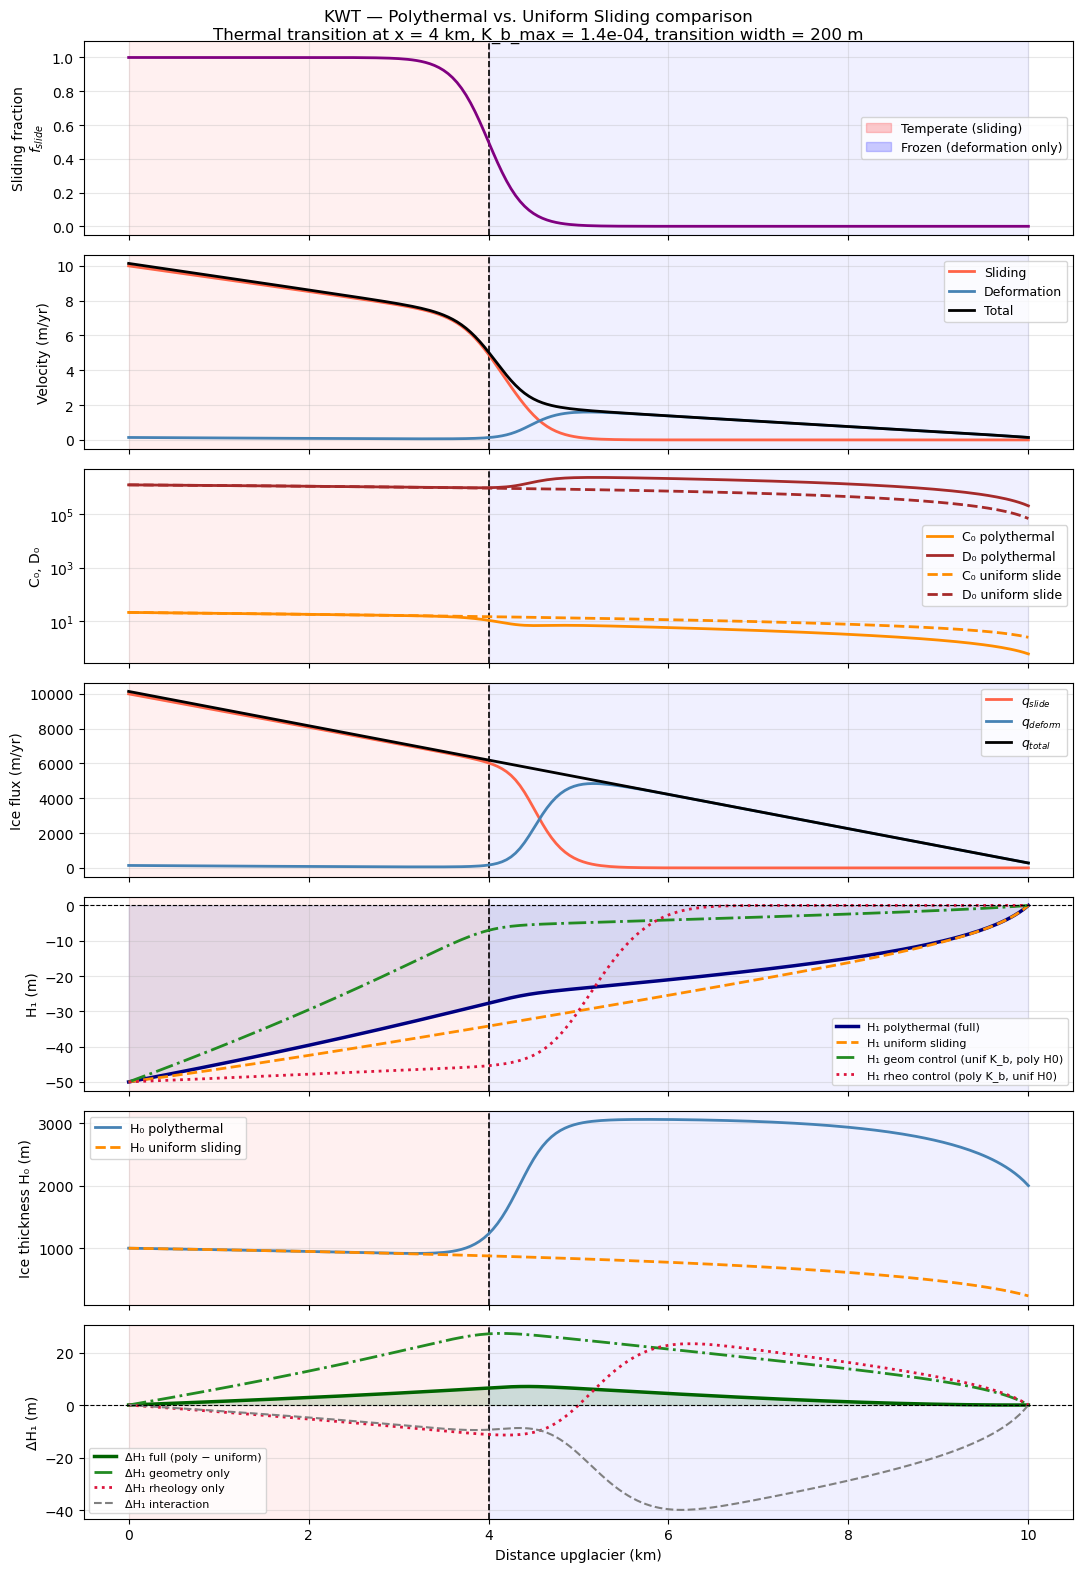

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

# ── Physical constants ────────────────────────────────────────────────────────
rho        = 917.0
g          = 9.81
n_glen     = 3
m_exp      = 1
sec_per_yr = 3.15e7

A_si  = 2.4e-23
A_yr  = A_si * sec_per_yr

# ══════════════════════════════════════════════════════════════════════════════
# DOMAIN
# ══════════════════════════════════════════════════════════════════════════════
nx               = 201
x                = np.linspace(0, 10_000, nx)
dx               = x[1] - x[0]
x_thermal        = 4_000.0
transition_width = 200.0

alpha0 = 0.008 - 0.004 * (x / x[-1])
alpha0 = np.maximum(alpha0, 0.001)

f_slide = 1.0 / (1.0 + np.exp((x - x_thermal) / transition_width))

# ══════════════════════════════════════════════════════════════════════════════
# SLIDING COEFFICIENT
# ══════════════════════════════════════════════════════════════════════════════
H_terminus = 1000.0
tau_t      = rho * g * H_terminus * alpha0[0]

u_slide_target = 10.0
K_b_max        = u_slide_target / tau_t
K_b            = K_b_max * f_slide

print(f"tau_terminus = {tau_t:.0f} Pa")
print(f"K_b_max      = {K_b_max:.3e}  m yr^-1 Pa^-1")
print(f"u_slide      = {K_b_max * tau_t:.2f} m/yr")
print(f"u_deform     = {(2*A_yr/(n_glen+1)) * tau_t**n_glen:.6f} m/yr")

# ══════════════════════════════════════════════════════════════════════════════
# MASS BALANCE
# ══════════════════════════════════════════════════════════════════════════════
q_slide_0  = K_b_max * tau_t * H_terminus
q_deform_0 = (2*A_yr/(n_glen+1)) * tau_t**n_glen * H_terminus
q0         = q_slide_0 + q_deform_0

H_max_target  = 2000.0
alpha_head    = alpha0[-1]
tau_head_test = rho * g * H_max_target * alpha_head
q_deform_head = (2*A_yr/(n_glen+1)) * tau_head_test**n_glen * H_max_target

b_dot = (q0 - q_deform_head) / x[-1]

print(f"\nq0             = {q0:.4f} m/yr")
print(f"q_deform_head  = {q_deform_head:.6f} m/yr  (at H={H_max_target:.0f} m)")
print(f"b_dot          = {b_dot:.4f} m/yr  ({b_dot*100:.2f} cm/yr accumulation)")

q_profile = q0 - b_dot * x
q_profile = np.maximum(q_profile, 0.01)

# ══════════════════════════════════════════════════════════════════════════════
# NEWTON SOLVER — shared geometry, used for BOTH base states
# ══════════════════════════════════════════════════════════════════════════════
def solve_H0(K_b_arr, alpha0, q_profile, H_terminus):
    nx = len(alpha0)
    H0 = np.zeros(nx)
    for i in range(nx):
        kb  = K_b_arr[i]
        al  = alpha0[i]
        q_t = q_profile[i]
        H   = H_terminus

        for _ in range(300):
            rga  = rho * g * al
            q    = kb * rga * H**2 + (2*A_yr/(n_glen+1)) * rga**n_glen * H**(n_glen+1)
            dqdH = 2*kb * rga * H  + (n_glen+1) * (2*A_yr/(n_glen+1)) * rga**n_glen * H**n_glen
            dH   = -(q - q_t) / dqdH
            dH   = np.clip(dH, -0.3*H, 2.0*H)
            H   += dH
            H    = max(H, 1.0)
            if abs(dH) < 1e-6:
                break
        H0[i] = H
    return H0

def solve_H0_joint(K_b, B, b_dot, H_terminus, dx, n=3, rho=910, g=9.81, A=2.4e-24):
    nx = len(B)
    H = np.ones(nx) * H_terminus  # initial guess
    
    for iteration in range(500):
        H_old = H.copy()
        
        # compute surface and slope from current H
        S = B + H
        alpha = -np.gradient(S, dx)
        alpha = np.clip(alpha, 1e-4, None)  # prevent negative slopes
        
        # compute flux from current H, alpha
        tau = rho * g * alpha * H
        q_slide = K_b * tau**2 * H        # ∝ K_b (ρgα)² H³  [check your exponents]
        q_deform = (2*A/(n+2)) * (rho*g*alpha)**n * H**(n+2)
        q = q_slide + q_deform
        
        # integrate mass conservation upstream from terminus
        # dq/dx = b_dot  →  q(x) = q_terminus + ∫ b_dot dx
        q_target = np.cumsum(b_dot[::-1])[::-1] * dx  # flux required at each x
        q_target += q[-1]  # anchor at terminus
        
        # invert q_target → H given current alpha
        H = invert_flux(q_target, K_b, alpha, n, rho, g, A)
        H = np.clip(H, 1.0, None)
        H[-1] = H_terminus  # boundary condition
        
        # relax update to stabilize
        H = 0.3 * H + 0.7 * H_old
        
        if np.max(np.abs(H - H_old)) < 0.01:
            print(f"Converged in {iteration} iterations")
            break
    
    return H


# ── Base state 1: polythermal (original) ─────────────────────────────────────
H0_poly = solve_H0(K_b, alpha0, q_profile, H_terminus)

# ── Base state 2: uniform sliding everywhere (f_slide = 1 everywhere) ────────
# Same K_b_max, same geometry, same q_profile — only difference is no thermal transition
K_b_uniform = np.full(nx, K_b_max)
H0_uniform  = solve_H0(K_b_uniform, alpha0, q_profile, H_terminus)

print(f"\nH0_poly    range: {H0_poly.min():.1f} – {H0_poly.max():.1f} m")
print(f"H0_uniform range: {H0_uniform.min():.1f} – {H0_uniform.max():.1f} m")





# ══════════════════════════════════════════════════════════════════════════════
# KWT COEFFICIENTS — computed for each base state
# ══════════════════════════════════════════════════════════════════════════════
def compute_kwt_coeffs(K_b_arr, H0, alpha0):
    C0 = (2*K_b_arr*(rho*g*alpha0)*H0
          + (n_glen+1)*(2*A_yr/(n_glen+1))*(rho*g*alpha0)**n_glen * H0**n_glen)
    D0 = (K_b_arr*(rho*g)*H0**2
          + n_glen*(2*A_yr/(n_glen+1))*(rho*g)**n_glen * alpha0**(n_glen-1) * H0**(n_glen+1))
    return C0, D0

C0_poly,    D0_poly    = compute_kwt_coeffs(K_b,         H0_poly,    alpha0)
C0_uniform, D0_uniform = compute_kwt_coeffs(K_b_uniform, H0_uniform, alpha0)
C0_geom,    D0_geom    = compute_kwt_coeffs(K_b_uniform, H0_poly,    alpha0)
C0_rheo, D0_rheo = compute_kwt_coeffs(K_b, H0_uniform, alpha0)

# Derived fields for plotting (polythermal)
tau0     = rho * g * H0_poly * alpha0
q_slide  = K_b         * tau0 * H0_poly
q_deform = (2*A_yr/(n_glen+1)) * tau0**n_glen * H0_poly
q_total  = q_slide + q_deform
u_slide  = K_b         * tau0
u_deform = (2*A_yr/(n_glen+1)) * tau0**n_glen
u_total  = u_slide + u_deform

print(f"\nPolythermal  — C0: {C0_poly.min():.2f}–{C0_poly.max():.2f}  "
      f"D0: {D0_poly.min():.1f}–{D0_poly.max():.1f}")
print(f"Uniform slide — C0: {C0_uniform.min():.2f}–{C0_uniform.max():.2f}  "
      f"D0: {D0_uniform.min():.1f}–{D0_uniform.max():.1f}")

# ══════════════════════════════════════════════════════════════════════════════
# KWT SOLVER
# ══════════════════════════════════════════════════════════════════════════════
def run_kwt(C0, D0, x, dh_front=-50, t_max=25):
    nx    = len(x)
    dx    = x[1] - x[0]
    dC0dx = np.gradient(C0, dx)
    dD0dx = np.gradient(D0, dx)

    eff_speed = np.abs(C0 - dD0dx)
    dt        = min(0.8 * dx / np.max(eff_speed),
                    0.4 * dx**2 / np.max(D0),
                    0.5)
    nt        = int(t_max / dt)
    print(f"  dt = {dt:.5f} yr,  nt = {nt:,}")

    r           = D0 * dt / dx**2
    ab          = np.zeros((3, nx))
    ab[1, 1:-1] = 1 + r[1:-1]
    ab[1, 0]    = 1.0
    ab[1, -1]   = 1.0
    ab[0, 2:]   = -0.5 * r[1:-1]
    ab[2, :-2]  = -0.5 * r[1:-1]

    H1    = np.zeros(nx)
    H1[0] = dh_front

    for step in range(nt):
        dH1dx     = np.zeros_like(H1)
        dH1dx[1:] = (H1[1:] - H1[:-1]) / dx

        adv_term   = -(H1 * dC0dx + (C0 - dD0dx) * dH1dx)

        rhs        = H1.copy()
        rhs[1:-1] += (0.5 * r[1:-1] * (H1[2:] - 2*H1[1:-1] + H1[:-2])
                      + dt * adv_term[1:-1])
        rhs[0]     = dh_front
        rhs[-1]    = 0.0

        H1         = solve_banded((1, 1), ab, rhs)
        H1[0]      = dh_front
        H1[-1]     = 0.0

        if not np.all(np.isfinite(H1)):
            print(f"  ⚠️  Divergence at step {step}")
            break

    return H1

print("\nRunning KWT — polythermal:")
H1_poly    = run_kwt(C0_poly,    D0_poly,    x, dh_front=-50, t_max=25)

print("Running KWT — uniform sliding:")
H1_uniform = run_kwt(C0_uniform, D0_uniform, x, dh_front=-50, t_max=25)

print("Running KWT — geometry only:")
H1_geom = run_kwt(C0_geom, D0_geom, x, dh_front=-50, t_max=25)
print("Running KWT — rheology only:")
H1_rheo = run_kwt(C0_rheo, D0_rheo, x, dh_front=-50, t_max=25)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(7, 1, figsize=(11, 16), sharex=True)

def shade_zones(ax):
    ax.axvspan(0,               x_thermal/1000, alpha=0.06, color='red')
    ax.axvspan(x_thermal/1000,  x[-1]/1000,     alpha=0.06, color='blue')
    ax.axvline(x_thermal/1000,  color='k', lw=1.2, ls='--')

for ax in axes:
    shade_zones(ax)

# Panel 0 — sliding fraction
axes[0].plot(x/1000, f_slide, 'purple', lw=2)
axes[0].set_ylabel("Sliding fraction\n$f_{slide}$")
axes[0].set_ylim(-0.05, 1.1)
axes[0].grid(True, alpha=0.3)
handles = [plt.Rectangle((0,0),1,1, color='red',  alpha=0.2),
           plt.Rectangle((0,0),1,1, color='blue', alpha=0.2)]
axes[0].legend(handles, ['Temperate (sliding)', 'Frozen (deformation only)'],
               fontsize=9, loc='center right')

# Panel 1 — velocity
axes[1].plot(x/1000, u_slide,  'tomato',     lw=2, label='Sliding')
axes[1].plot(x/1000, u_deform, 'steelblue',  lw=2, label='Deformation')
axes[1].plot(x/1000, u_total,  'k',          lw=2, label='Total')
axes[1].set_ylabel("Velocity (m/yr)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Panel 2 — C0, D0
axes[2].plot(x/1000, C0_poly,    'darkorange', lw=2,          label='C₀ polythermal')
axes[2].plot(x/1000, D0_poly,    'brown',      lw=2,          label='D₀ polythermal')
axes[2].plot(x/1000, C0_uniform, 'darkorange', lw=2, ls='--', label='C₀ uniform slide')
axes[2].plot(x/1000, D0_uniform, 'brown',      lw=2, ls='--', label='D₀ uniform slide')
axes[2].set_ylabel("C₀, D₀")
axes[2].set_yscale('log')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

# Panel 3 — ice flux
axes[3].plot(x/1000, q_slide,  'tomato',    lw=2, label='$q_{slide}$')
axes[3].plot(x/1000, q_deform, 'steelblue', lw=2, label='$q_{deform}$')
axes[3].plot(x/1000, q_total,  'k',         lw=2, label='$q_{total}$')
axes[3].set_ylabel("Ice flux (m/yr)")
axes[3].legend(fontsize=9)
axes[3].grid(True, alpha=0.3)

# Panel 4 — H1 four-way comparison
axes[4].plot(x/1000, H1_poly,    'navy',       lw=2.5, label='H₁ polythermal (full)')
axes[4].plot(x/1000, H1_uniform, 'darkorange', lw=2,   label='H₁ uniform sliding',    ls='--')
axes[4].plot(x/1000, H1_geom,    'forestgreen',lw=2,   label='H₁ geom control (unif K_b, poly H0)', ls='-.')
axes[4].plot(x/1000, H1_rheo,    'crimson',    lw=2,   label='H₁ rheo control (poly K_b, unif H0)', ls=':')
axes[4].axhline(0, color='k', lw=0.8, ls='--')
axes[4].fill_between(x/1000, 0, H1_poly,
                     where=H1_poly < 0, alpha=0.10, color='navy')
axes[4].set_ylabel("H₁ (m)")
axes[4].legend(fontsize=8, loc='lower right')
axes[4].grid(True, alpha=0.3)

# Panel 5 — H0 comparison
axes[5].plot(x/1000, H0_poly,    'steelblue',  lw=2,   label='H₀ polythermal')
axes[5].plot(x/1000, H0_uniform, 'darkorange', lw=2, ls='--', label='H₀ uniform sliding')
axes[5].set_ylabel("Ice thickness H₀ (m)")
axes[5].legend(fontsize=9)
axes[5].grid(True, alpha=0.3)

# Panel 6 — decomposed differences
diff_full = H1_poly    - H1_uniform   # total effect
diff_geom = H1_geom    - H1_uniform   # pure geometry
diff_rheo = H1_rheo    - H1_uniform   # pure rheology
diff_int  = diff_full - diff_geom - diff_rheo  # interaction term

axes[6].plot(x/1000, diff_full, 'darkgreen', lw=2.5, label='ΔH₁ full (poly − uniform)')
axes[6].plot(x/1000, diff_geom, 'forestgreen', lw=2, label='ΔH₁ geometry only',  ls='-.')
axes[6].plot(x/1000, diff_rheo, 'crimson',     lw=2, label='ΔH₁ rheology only',  ls=':')
axes[6].plot(x/1000, diff_int,  'gray',        lw=1.5, label='ΔH₁ interaction',  ls='--')
axes[6].axhline(0, color='k', lw=0.8, ls='--')
axes[6].fill_between(x/1000, 0, diff_full, alpha=0.15, color='darkgreen')
axes[6].set_ylabel("ΔH₁ (m)")
axes[6].set_xlabel("Distance upglacier (km)")
axes[6].legend(fontsize=8)
axes[6].grid(True, alpha=0.3)

plt.suptitle(
    f"KWT — Polythermal vs. Uniform Sliding comparison\n"
    f"Thermal transition at x = {x_thermal/1000:.0f} km, "
    f"K_b_max = {K_b_max:.1e}, transition width = {transition_width:.0f} m",
    fontsize=12
)
plt.tight_layout()
plt.savefig("figs/kwt_combined_flux.png", dpi=300)
plt.show()
